# День 1. Тензоры — фундамент PyTorch

## 1. Введение: от скрипта к глубокому пониманию

В Дне 0 ты установил PyTorch, запустил `check_env.py` и увидел, что тензор — это объект с `.shape`, `.dtype` и `.device`. Сегодня мы **полностью разберём**, что такое тензор, как с ним работать, как он устроен в памяти, и почему некоторые операции «ломаются», а другие — нет.

**Цель дня:** после этого конспекта ты должен чувствовать себя с тензорами так же уверенно, как с обычными Python-списками. Без этого фундамента все следующие дни (autograd, `nn.Module`, обучение) будут строиться на песке.

**Что будет:**
- Тензоры как объекты: не просто «массивы», а структуры с метаданными.
- Все способы создания, изменения формы, индексации.
- Broadcasting — правила, которые ломают голову 90% новичков.
- In-place операции — почему `add_()` опасен, но быстр.
- Memory layout — что такое `stride` и `contiguous`, и почему `view()` иногда падает.
- Практика: линейная регрессия **вручную** на голых тензорах. Без `autograd`, без `nn.Linear`. Чтобы почувствовать, что PyTorch — это просто NumPy с GPU, а магия появится позже.

## 2. Тензор как объект: четыре столпа

Каждый `torch.Tensor` — это не просто набор чисел. Это **структура из четырёх компонентов**:

In [ ]:
┌─────────────────────────────────────────┐
│           torch.Tensor                  │
├─────────────────────────────────────────┤
│  1. Данные (storage)                    │
│     -> физический массив чисел в памяти │
├─────────────────────────────────────────┤
│  2. Форма (shape)                       │
│     -> как интерпретировать storage     │
├─────────────────────────────────────────┤
│  3. Тип данных (dtype)                  │
│     -> сколько байт на число, int/float │
├─────────────────────────────────────────┤
│  4. Устройство (device)                 │
│     -> CPU RAM или GPU VRAM             │
├─────────────────────────────────────────┤
│  5. Флаг градиентов (requires_grad)     │
│     -> отслеживать операции? (День 2)   │
└─────────────────────────────────────────┘

**Ключевой инсайт:** одни и те же данные в памяти можно интерпретировать по-разному, меняя только `shape` и `stride`. Это и делает PyTorch быстрым — он не копирует данные, а только меняет «взгляд» на них.

## 3. Создание тензоров: полный арсенал

### 3.1. Из Python-данных

In [ ]:
import torch

# Из списка (list)
a = torch.tensor([1, 2, 3])
print(a)        # tensor([1, 2, 3])
print(a.dtype)  # torch.int64 (потому что Python int = 64-битный)

# Из списка с float
b = torch.tensor([1.0, 2.0, 3.0])
print(b.dtype)  # torch.float32 (по умолчанию для float)

# Из вложенного списка (матрица)
c = torch.tensor([[1, 2], [3, 4], [5, 6]])
print(c.shape)  # torch.Size([3, 2])

# Явное указание типа
d = torch.tensor([1, 2, 3], dtype=torch.float32)
print(d.dtype)  # torch.float32

# Явное указание устройства
e = torch.tensor([1.0, 2.0], device='cpu')  # или 'cuda', 'mps'

**Важно:** `torch.tensor()` **всегда копирует данные**. Если ты передаёшь NumPy-массив, он скопируется. Если хочешь разделить память (zero-copy), используй `torch.from_numpy()` (см. раздел 8).

### 3.2. Специальные конструкторы

In [ ]:
import torch

# Нули — инициализация весов, маски
z = torch.zeros(2, 3)
# tensor([[0., 0., 0.],
#         [0., 0., 0.]])

# Единицы — например, для bias
o = torch.ones(3, 3)

# Случайные [0, 1) — равномерное распределение
r = torch.rand(2, 3)  # каждый элемент ~ Uniform(0, 1)

# Случайные из нормального распределения N(0, 1)
# ЭТО САМЫЙ ВАЖНЫЙ КОНСТРУКТОР для инициализации весов нейросетей!
n = torch.randn(2, 3)  # каждый элемент ~ N(0, 1)

# Арифметическая прогрессия
a = torch.arange(0, 10, 2)   # tensor([0, 2, 4, 6, 8])
# start=0, end=10 (не включая!), step=2

# Равномерное разбиение интервала (полезно для графиков)
l = torch.linspace(0, 1, 5)  
# tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
# 5 точек от 0 до 1 включительно

# Пустой тензор (неинициализированная память!)
# Быстрее zeros, но содержит мусор. Используй ТОЛЬКО если сразу перезапишешь.
e = torch.empty(2, 3)

# Полный аналог существующего тензора (та же форма и тип)
x = torch.tensor([[1, 2], [3, 4]])
z_like = torch.zeros_like(x)  # tensor([[0, 0], [0, 0]])
o_like = torch.ones_like(x)   # tensor([[1, 1], [1, 1]])
r_like = torch.rand_like(x, dtype=torch.float32)  # случайные, та же форма

### 3.3. Создание тензоров на GPU

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Способ 1: указать при создании
x = torch.randn(3, 3, device=device)

# Способ 2: создать на CPU, потом перенести
x = torch.randn(3, 3)
x = x.to(device)

# Способ 3: для конкретного устройства
x = torch.randn(3, 3).cuda()   # только если CUDA доступна
x = torch.randn(3, 3).cpu()    # явно на CPU

## 4. Типы данных (`dtype`): зачем столько?

### 4.1. Полная таблица

| PyTorch тип | Алиас | Размер | NumPy аналог | Когда использовать |
|:---|:---|:---|:---|:---|
| `torch.float32` | `torch.float` | 4 байта | `float32` | **Стандарт DL**. Все веса, активации, градиенты. |
| `torch.float64` | `torch.double` | 8 байт | `float64` | Высокая точность (редко). |
| `torch.float16` | — | 2 байта | `float16` | Экономия памяти GPU (mixed precision). |
| `torch.bfloat16` | — | 2 байта | — | Альтернатива float16 (меньше проблем с переполнением). |
| `torch.int64` | `torch.long` | 8 байт | `int64` | **Индексы, метки классов**. |
| `torch.int32` | `torch.int` | 4 байта | `int32` | Счётчики, небольшие индексы. |
| `torch.int8` | — | 1 байт | `int8` | Квантизация (компактное хранение). |
| `torch.bool` | — | 1 байт | `bool_` | Маски, булевы условия. |

### 4.2. Почему float32, а не float64?

1. **Память:** модель с 10 млн параметров в float32 занимает 40 МБ. В float64 — 80 МБ.
2. **Скорость:** GPU вычисляют float32 в 2–4 раза быстрее, чем float64. На современных GPU (Tensor Cores) — в 8–16 раз быстрее.
3. **Точности хватает:** в DL нам не нужна точность до 15-го знака. Градиентный спуск и так шумный.

### 4.3. Почему метки классов — int64?

Функция потерь `CrossEntropyLoss` ожидает метки типа `torch.long` (int64). Если передать `int32`, будет ошибка:

In [ ]:
# ОШИБКА:
labels = torch.tensor([0, 1, 2], dtype=torch.int32)
loss = torch.nn.CrossEntropyLoss()(logits, labels)
# RuntimeError: expected scalar type Long but found Int

# ПРАВИЛЬНО:
labels = torch.tensor([0, 1, 2], dtype=torch.long)  # или torch.int64

### 4.4. Преобразование типов

In [ ]:
x = torch.tensor([1, 2, 3])        # int64
print(x.dtype)                     # torch.int64

x_float = x.float()                # int64 -> float32
x_double = x.double()              # int64 -> float64
x_int = x_float.long()             # float32 -> int64 (округляет вниз!)
x_bool = x.bool()                  # int64 -> bool (0->False, остальное->True)

# Альтернативный синтаксис
x = x.to(torch.float32)            # универсальный способ
x = x.type(torch.float32)          # то же самое

**Ловушка:** `x.long()` на float тензоре **округляет вниз** (truncation), а не по правилам математики:

In [ ]:
x = torch.tensor([1.9, 2.1, -1.9])
print(x.long())  # tensor([ 1,  2, -1])

## 5. Форма и размерность: shape, ndim, numel

### 5.1. Базовые атрибуты

In [ ]:
x = torch.randn(2, 3, 4)  # 3-мерный тензор

print(x.shape)    # torch.Size([2, 3, 4])
print(x.ndim)     # 3 (количество измерений)
print(x.numel())  # 24 (общее количество элементов: 2*3*4)

**Как читать `.shape`:** справа налево, от «внутреннего» к «внешнему»:
- `torch.Size([2, 3, 4])` = 2 объекта, каждый — матрица 3×4.
- В контексте батча картинок (без каналов): `[batch_size, height, width]`.
- В контексте батча картинок (с каналами): `[batch_size, channels, height, width]`.

### 5.2. Изменение формы: reshape, view, flatten, squeeze, unsqueeze

#### `reshape()` — самый безопасный способ

In [ ]:
x = torch.arange(12)        # tensor([0, 1, 2, ..., 11]), shape [12]
x = x.reshape(3, 4)         # shape [3, 4]
print(x)
# tensor([[ 0,  1,  2,  3],
#         [ 4,  5,  6,  7],
#         [ 8,  9, 10, 11]])

# Можно указать -1 — PyTorch сам вычислит размер
x = x.reshape(2, -1)        # shape [2, 6] (-1 = 12/2 = 6)
x = x.reshape(-1)           # shape [12] (вытянуть в вектор)

**Правило:** общее количество элементов должно совпадать. `3*4 = 12`, `2*6 = 12`.

#### `view()` — быстрый, но требует непрерывности памяти

In [ ]:
x = torch.arange(12).reshape(3, 4)
y = x.view(2, 6)            # работает, потому что x contiguous

**Разница `view()` vs `reshape()`:**
- `view()` — всегда возвращает **view** (общая память с оригиналом). Но работает только если данные в памяти **непрерывны** (contiguous).
- `reshape()` — возвращает view, если может. Если не может (данные не contiguous) — **копирует** данные и возвращает новый тензор.

In [ ]:
x = torch.arange(12).reshape(3, 4)
print(x.is_contiguous())    # True

# Транспонируем — данные перестают быть contiguous
xt = x.t()                  # или x.transpose(0, 1)
print(xt.is_contiguous())   # False

# view() УПАДЁТ:
# xt.view(2, 6)  # RuntimeError: view size is not compatible...

# reshape() СРАБОТАЕТ (скопирует данные):
yt = xt.reshape(2, 6)       # OK!

**Практический совет:** используй `reshape()` всегда, когда не уверен. Используй `view()` только в горячем коде, где критична скорость и ты гарантируешь contiguous.

#### `flatten()` — вытягивание в вектор

In [ ]:
x = torch.randn(2, 3, 4)
y = x.flatten()             # shape [24]
z = x.flatten(start_dim=1)  # shape [2, 12] — вытянуть только с dim=1

#### `squeeze()` и `unsqueeze()` — добавление/удаление размерностей размером 1

In [ ]:
x = torch.randn(3, 1, 4)    # shape [3, 1, 4]

y = x.squeeze()             # shape [3, 4] — убрал ВСЕ размерности 1
y = x.squeeze(dim=1)        # shape [3, 4] — убрал только dim=1

z = y.unsqueeze(dim=1)      # shape [3, 1, 4] — добавил размерность 1 на позицию 1
z = y.unsqueeze(0)          # shape [1, 3, 4] — добавил в начало

# Практика: подготовка вектора к матричному умножению
v = torch.randn(3)          # [3]
v = v.unsqueeze(1)          # [3, 1] — теперь это столбец
v = v.unsqueeze(0)          # [1, 3] — теперь это строка

## 6. Индексация и слайсы

### 6.1. Базовая индексация

In [ ]:
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])

# Элемент
print(x[1, 2])      # tensor(6) — 2-я строка, 3-й столбец (нумерация с 0!)

# Строка
print(x[1])         # tensor([4, 5, 6])

# Столбец
print(x[:, 1])      # tensor([2, 5, 8]) — ВСЕ строки, 2-й столбец

# Подматрица
print(x[0:2, 1:3])  # tensor([[2, 3],
                    #         [5, 6]])

### 6.2. Булева индексация (маски)

In [ ]:
x = torch.tensor([1, 2, 3, 4, 5])

# Маска
mask = x > 3
print(mask)         # tensor([False, False, False, True, True])

# Применение маски
print(x[mask])      # tensor([4, 5])

# Комбинирование условий
print(x[(x > 2) & (x < 5)])   # tensor([3, 4])  # & — поэлементное И
print(x[(x < 2) | (x > 4)])   # tensor([1, 5])  # | — поэлементное ИЛИ

# Присваивание по маске
x[x > 3] = 0
print(x)            # tensor([1, 2, 3, 0, 0])

**Важно:** булева индексация **всегда возвращает копию**, never view.

### 6.3. Fancy indexing (индексация списком/тензором индексов)

In [ ]:
x = torch.tensor([10, 20, 30, 40, 50])

# Индексы — тензор
indices = torch.tensor([0, 2, 4])
print(x[indices])   # tensor([10, 30, 50])

# Многомерная fancy indexing
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])
rows = torch.tensor([0, 2])
cols = torch.tensor([1, 2])
print(x[rows, cols])  # tensor([2, 9]) — x[0,1] и x[2,2]

**Важно:** fancy indexing тоже возвращает **копию**.

### 6.4. Копии vs Views: критически важное различие

| Операция | Возвращает | Изменения отражаются в оригинале? |
|:---|:---|:---|
| `x[i]` (скаляр) | копия | Нет |
| `x[i:j]` (слайс) | **view** | **Да** |
| `x.view(...)` | **view** | **Да** |
| `x.reshape(...)` | view или копия | Зависит |
| `x[mask]` (булева) | копия | Нет |
| `x[indices]` (fancy) | копия | Нет |
| `x.t()` / `x.transpose()` | **view** | **Да** |
| `x.clone()` | копия | Нет |

In [ ]:
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])

# Слайс — VIEW
y = x[0, :]         # первая строка
y[0] = 999
print(x)            # tensor([[999,   2,   3],
                    #         [  4,   5,   6]])  <- ОРИГИНАЛ ИЗМЕНИЛСЯ!

# Если нужна независимая копия:
z = x[0, :].clone()
z[0] = 111
print(x)            # tensor([[999,   2,   3], ...]) <- оригинал НЕ изменился

**Практическое правило:** если ты собираешься **изменять** результат индексации/слайса, и не хочешь ломать оригинал — добавляй `.clone()`.

## 7. Операции с тензорами

### 7.1. Поэлементные операции

In [ ]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

# Арифметика
print(a + b)        # tensor([5., 7., 9.])
print(a - b)        # tensor([-3., -3., -3.])
print(a * b)        # tensor([ 4., 10., 18.])  — поэлементное умножение!
print(a / b)        # tensor([0.2500, 0.4000, 0.5000])
print(a ** 2)       # tensor([1., 4., 9.])

# Сравнения (возвращают bool)
print(a > 2)        # tensor([False, False, True])
print(a == b)       # tensor([False, False, False])

# Математические функции
print(torch.sqrt(a))     # tensor([1.0000, 1.4142, 1.7321])
print(torch.exp(a))      # e^x
print(torch.log(a))      # натуральный логарифм
print(torch.sin(a))      # синус

### 7.2. Операции редукции (схлопывание размерности)

In [ ]:
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

# Сумма всех элементов
print(torch.sum(x))         # tensor(21.)
print(x.sum())              # то же самое (метод объекта)

# Сумма по строкам (dim=0 — схлопываем строки)
print(x.sum(dim=0))         # tensor([5., 7., 9.])  # 1+4, 2+5, 3+6

# Сумма по столбцам (dim=1 — схлопываем столбцы)
print(x.sum(dim=1))         # tensor([ 6., 15.])  # 1+2+3, 4+5+6

# Среднее
print(x.mean())             # tensor(3.5)
print(x.mean(dim=0))        # tensor([2.5, 3.5, 4.5])

# Максимум и argmax (индекс максимума)
print(x.max())              # tensor(6.) — глобальный максимум
print(x.max(dim=1))         # torch.return_types.max(values=tensor([3., 6.]), indices=tensor([2, 2]))
# values — максимумы по каждой строке, indices — их позиции

# Альтернатива:
print(torch.max(x, dim=1))  # то же самое

**Критически важно: параметр `keepdim`**

In [ ]:
x = torch.randn(3, 4)

# Без keepdim:
m = x.mean(dim=1)
print(m.shape)          # torch.Size([3]) — размерность «схлопнулась»

# С keepdim:
m = x.mean(dim=1, keepdim=True)
print(m.shape)          # torch.Size([3, 1]) — размерность сохранена!

# Зачем? Для broadcasting при вычитании среднего:
x_centered = x - x.mean(dim=1, keepdim=True)  # работает!
# x - x.mean(dim=1)  # ОШИБКА! shape [3,4] - shape [3] — broadcasting не сработает так, как нужно

### 7.3. Матричное умножение

In [ ]:
a = torch.randn(2, 3)   # матрица 2×3
b = torch.randn(3, 4)   # матрица 3×4

# Способ 1: оператор @
c = a @ b               # shape [2, 4]

# Способ 2: torch.matmul
c = torch.matmul(a, b)  # shape [2, 4]

# Способ 3: .mm() — только для 2D
c = a.mm(b)             # shape [2, 4]

# BATCH матричное умножение (для 3D тензоров)
a = torch.randn(10, 3, 4)   # 10 матриц 3×4
b = torch.randn(10, 4, 5)   # 10 матриц 4×5
c = torch.bmm(a, b)         # 10 матриц 3×5, shape [10, 3, 5]

**Правило размерностей для `@` / `matmul`:**

In [ ]:
[..., m, n] @ [..., n, p] = [..., m, p]

Внутренние размерности (`...`) должны совпадать (или broadcast'иться), а `n` — обязательно одинаковая.

### 7.4. Транспонирование

In [ ]:
x = torch.randn(2, 3, 4)

# Транспонировать две размерности
y = x.transpose(0, 2)   # меняем местами dim=0 и dim=2 -> shape [4, 3, 2]

# Транспонировать последние две (как в линейной алгебре)
z = x.transpose(-2, -1)  # shape [2, 4, 3]

# Для 2D — короткая запись
a = torch.randn(3, 4)
print(a.t())             # shape [4, 3], то же что a.transpose(0, 1)

# Перестановка всех размерностей
w = x.permute(2, 0, 1)   # shape [4, 2, 3] — полная перестановка

**Важно:** `transpose()` и `permute()` возвращают **view** (общая память). `t()` — тоже view.

## 8. Broadcasting: правила расширения размерностей

Broadcasting — это механизм, позволяющий выполнять операции над тензорами **разной формы** без явного копирования.

### 8.1. Правила (алгоритм)

1. Выравниваем размерности **справа налево** (от меньших к большим).
2. Для каждой пары размерностей:
   - Одинаковые -> OK.
   - Одна из них = 1 -> расширяем до размера другой (виртуально, без копирования).
   - Разные и ни одна ≠ 1 -> **ОШИБКА**.

### 8.2. Примеры

In [ ]:
# Пример 1: скаляр + вектор
a = torch.tensor([1.0, 2.0, 3.0])   # shape [3]
b = 2.0                              # shape [] (скаляр)
print(a + b)                         # tensor([3., 4., 5.])
# Broadcasting: [] -> [1] -> [3]

# Пример 2: вектор-столбец + вектор-строка
a = torch.tensor([[1.0],            # shape [3, 1]
                  [2.0],
                  [3.0]])
b = torch.tensor([10.0, 20.0, 30.0]) # shape [3]
print(a + b)
# tensor([[11., 21., 31.],
#         [12., 22., 32.],
#         [13., 23., 33.]])
# Broadcasting: [3,1] + [3] -> [3,1] + [1,3] -> [3,3]

# Пример 3: батч + смещение
batch = torch.randn(10, 3, 4)        # 10 матриц 3×4
bias = torch.randn(4)                 # shape [4]
result = batch + bias                 # bias добавляется к КАЖДОЙ строке КАЖДОЙ матрицы
# Broadcasting: [10, 3, 4] + [4] -> [10, 3, 4] + [1, 1, 4] -> [10, 3, 4]

### 8.3. Типичная ошибка

In [ ]:
a = torch.randn(3, 4)    # [3, 4]
b = torch.randn(3)       # [3]

# ОШИБКА:
# a + b  # RuntimeError: The size of tensor a (4) must match...
# Почему? Выравниваем справа налево:
#   a: [3, 4]
#   b: [   3]
# 4 vs 3 — разные, ни одна не 1 -> ошибка!

# ИСПРАВЛЕНИЕ:
b = b.unsqueeze(1)       # [3, 1]
result = a + b           # OK! [3,4] + [3,1] -> [3,4]

### 8.4. Практическое применение broadcasting

In [ ]:
# Нормализация по батчу (предварительная версия BatchNorm)
x = torch.randn(10, 3, 32, 32)   # 10 картинок, 3 канала, 32×32

# Среднее по батчу: [10, 3, 32, 32] -> [3, 32, 32]
mean = x.mean(dim=0, keepdim=True)  # shape [1, 3, 32, 32]

# Нормализация
x_norm = x - mean  # broadcasting: [10,3,32,32] - [1,3,32,32] -> [10,3,32,32]

## 9. In-place операции: `_` в конце имени

### 9.1. Что это

In-place операции **модифицируют тензор на месте**, не создавая новый объект.

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])

# Обычная операция (возвращает НОВЫЙ тензор)
y = x.add(10)
print(x)  # tensor([1., 2., 3.]) — x не изменился!
print(y)  # tensor([11., 12., 13.])

# In-place операция (модифицирует x)
x.add_(10)
print(x)  # tensor([11., 12., 13.]) — x ИЗМЕНИЛСЯ!

**Соглашение именования:** in-place версия всегда оканчивается на `_`:
- `add()` -> `add_()`
- `mul()` -> `mul_()`
- `zero_()` — заполнить нулями
- `normal_()` — заполнить случайными из нормального распределения
- `uniform_()` — заполнить случайными из равномерного

### 9.2. Почему опасны при autograd

**Это предупреждение на будущее (День 2).**

Когда `requires_grad=True`, PyTorch строит вычислительный граф. In-place операции **разрушают** этот граф, потому что перезаписывают данные, которые нужны для вычисления градиентов.

In [ ]:
x = torch.tensor([2.0], requires_grad=True)
y = x * 3
x.add_(1)        # in-place! разрушает граф
y.backward()     # может выдать ошибку или неверный градиент

**Правило:** никогда не используй in-place операции на тензорах с `requires_grad=True`, если не уверен на 100%.

### 9.3. Когда полезны

In-place операции экономят память — не создают копии. Полезны при:
- Инициализации весов: `w.normal_(0, 0.01)`
- Обнулении градиентов: `grad.zero_()`
- Инференсе (когда `requires_grad=False`)

## 10. Взаимодействие с NumPy и Python

### 10.1. Тензор -> NumPy: `.numpy()`

In [ ]:
import torch
import numpy as np

t = torch.tensor([1, 2, 3])
n = t.numpy()
print(n)        # [1 2 3]
print(type(n))  # <class 'numpy.ndarray'>

**Важно:** `.numpy()` возвращает **view** (общая память), если тензор на CPU. Изменения отражаются:

In [ ]:
t = torch.tensor([1, 2, 3])
n = t.numpy()
n[0] = 999
print(t)        # tensor([999,   2,   3])

**Но:** если тензор на GPU, `.numpy()` **упадёт**:

In [ ]:
t = torch.tensor([1, 2, 3], device='cuda')
# n = t.numpy()  # TypeError: can't convert cuda:0 device type tensor...
# Нужно сначала на CPU:
n = t.cpu().numpy()

### 10.2. NumPy -> тензор: `torch.from_numpy()`

In [ ]:
n = np.array([1, 2, 3])
t = torch.from_numpy(n)
print(t)        # tensor([1, 2, 3])
print(t.dtype)  # torch.int64 (тип numpy int64)

**Важно:** `torch.from_numpy()` — **zero-copy** (общая память):

In [ ]:
n = np.array([1, 2, 3])
t = torch.from_numpy(n)
n[0] = 999
print(t)        # tensor([999,   2,   3])

**Если нужна копия** (независимая память):

In [ ]:
t = torch.tensor(n)        # копия
t = torch.from_numpy(n).clone()  # копия

### 10.3. Скаляр -> Python: `.item()`

In [ ]:
x = torch.tensor([42.0])
# print(x + 5)  # tensor([47.]) — остаётся тензором

val = x.item()   # извлекает Python float из скалярного тензора
print(val)       # 42.0
print(type(val)) # <class 'float'>

# Для многомерного тензора item() упадёт:
y = torch.tensor([1, 2, 3])
# y.item()  # RuntimeError: a Tensor with 3 elements cannot be converted to Scalar

### 10.4. Тензор -> Python-список: `.tolist()`

In [ ]:
t = torch.tensor([[1, 2], [3, 4]])
lst = t.tolist()
print(lst)       # [[1, 2], [3, 4]]
print(type(lst)) # <class 'list'>

## 11. Memory layout: stride, contiguous

### 11.1. Что такое stride

`stride` — это количество байт (точнее, элементов), которые нужно пропустить в физической памяти, чтобы перейти к следующему элементу по каждой размерности.

In [ ]:
x = torch.arange(12).reshape(3, 4)
print(x)
# tensor([[ 0,  1,  2,  3],
#         [ 4,  5,  6,  7],
#         [ 8,  9, 10, 11]])

print(x.stride())  # (4, 1)

**Как читать `(4, 1)`:**
- Чтобы перейти к следующей строке (dim=0), нужно сдвинуться на 4 элемента в памяти.
- Чтобы перейти к следующему столбцу (dim=1), нужно сдвинуться на 1 элемент.

Это логично: данные лежат в памяти как `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]`. Чтобы перейти от `0` к `4` (следующая строка), сдвигаемся на 4. Чтобы перейти от `0` к `1` (следующий столбец), сдвигаемся на 1.

### 11.2. Что такое contiguous

Тензор **contiguous** — если его элементы в физической памяти лежат в том же порядке, что и при линейном обходе (последняя размерность меняется быстрее всего).

In [ ]:
x = torch.arange(12).reshape(3, 4)
print(x.is_contiguous())     # True

# Транспонируем
xt = x.t()
print(xt.is_contiguous())    # False!
print(xt.stride())           # (1, 4) — вместо (4, 1)

**Почему `xt` не contiguous?** Данные в памяти всё ещё `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]`. Но `xt[0, 1]` — это `4` (бывший `x[1, 0]`). Чтобы перейти к следующему элементу строки `xt`, нужно сдвинуться на 4 элемента в памяти. Это «неестественный» порядок.

### 11.3. `.contiguous()` — принудительное упорядочивание

In [ ]:
xt = x.t()                   # не contiguous
xtc = xt.contiguous()        # КОПИРУЕТ данные в «правильном» порядке
print(xtc.is_contiguous())   # True
print(xtc.stride())          # (3, 1)

**Когда нужно:**
- Перед `view()` (который требует contiguous).
- Перед передачей в某些 C-расширения.
- Когда ты собираешься много раз обращаться к элементам — contiguous быстрее из-за кэша CPU/GPU.

## 12. Практика: линейная регрессия вручную

### 12.1. Постановка задачи

У нас есть данные, сгенерированные по формуле:

In [ ]:
y = 2 * x + 1 + noise

где `noise ~ N(0, 0.5)`.

Мы хотим найти параметры `w` (наклон) и `b` (сдвиг), минимизируя **MSE (Mean Squared Error)**:

In [ ]:
MSE = (1/N) * sum((y_pred - y_true)^2)

### 12.2. Аналитические градиенты

Для MSE:

In [ ]:
d(MSE)/dw = (2/N) * sum((y_pred - y) * x)
d(MSE)/db = (2/N) * sum(y_pred - y)

### 12.3. Полный код

In [ ]:
"""
day1_linear_regression_manual.py
Линейная регрессия вручную на голых тензорах PyTorch.
Без autograd, без nn.Module — только тензоры и формулы.
"""

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
# ============================================
# 1. Генерация синтетических данных
# ============================================

torch.manual_seed(42)  # для воспроизводимости

N = 100                          # количество точек
X = torch.linspace(0, 10, N)     # 100 точек от 0 до 10
true_w = 2.0                     # истинный наклон
true_b = 1.0                     # истинный сдвиг
noise = torch.randn(N) * 0.5     # шум ~ N(0, 0.5)

Y = true_w * X + true_b + noise  # y = 2x + 1 + noise

print(f"Форма X: {X.shape}")     # torch.Size([100])
print(f"Форма Y: {Y.shape}")     # torch.Size([100])

Форма X: torch.Size([100])
Форма Y: torch.Size([100])


In [13]:
# ============================================
# 2. Инициализация параметров
# ============================================

# Начальные значения — случайные
w = torch.tensor(0.0, requires_grad=False)   # наклон
b = torch.tensor(0.0, requires_grad=False)   # сдвиг

print(f"Начальные параметры: w={w.item():.4f}, b={b.item():.4f}")

Начальные параметры: w=0.0000, b=0.0000


In [8]:
# ============================================
# 3. Гиперпараметры
# ============================================

learning_rate = 0.01
n_epochs = 1000

# Для визуализации
loss_history = []

In [9]:
# ============================================
# 4. Цикл обучения
# ============================================

for epoch in range(n_epochs):
    # --- Forward pass: предсказание ---
    Y_pred = w * X + b
    
    # --- Вычисление ошибки (MSE) ---
    diff = Y_pred - Y
    loss = (diff ** 2).mean()   # MSE = среднее квадратов ошибок
    loss_history.append(loss.item())
    
    # --- Вычисление градиентов ВРУЧНУЮ ---
    # d(MSE)/dw = (2/N) * sum((y_pred - y) * x)
    # d(MSE)/db = (2/N) * sum(y_pred - y)
    grad_w = (2.0 / N) * (diff * X).sum()
    grad_b = (2.0 / N) * diff.sum()
    
    # --- Обновление параметров (градиентный спуск) ---
    # ВАЖНО: обновляем через ПРИСВАИВАНИЕ, а не in-place!
    # Потому что w и b — скаляры, и in-place сломает вычисления в следующей итерации
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b
    
    # --- Логирование ---
    if (epoch + 1) % 100 == 0:
        print(f"Эпоха {epoch+1:4d}: loss={loss.item():.6f}, w={w.item():.4f}, b={b.item():.4f}")

Эпоха  100: loss=0.290928, w=2.0636, b=0.6021
Эпоха  200: loss=0.259282, w=2.0375, b=0.7756
Эпоха  300: loss=0.247584, w=2.0216, b=0.8811
Эпоха  400: loss=0.243261, w=2.0120, b=0.9452
Эпоха  500: loss=0.241663, w=2.0061, b=0.9842
Эпоха  600: loss=0.241072, w=2.0026, b=1.0079
Эпоха  700: loss=0.240854, w=2.0004, b=1.0223
Эпоха  800: loss=0.240773, w=1.9991, b=1.0310
Эпоха  900: loss=0.240743, w=1.9983, b=1.0364
Эпоха 1000: loss=0.240732, w=1.9978, b=1.0396


In [10]:
# ============================================
# 5. Результаты
# ============================================

print(f"\n{'='*50}")
print(f"Истинные параметры:     w={true_w:.4f}, b={true_b:.4f}")
print(f"Найденные параметры:    w={w.item():.4f}, b={b.item():.4f}")
print(f"{'='*50}")


Истинные параметры:     w=2.0000, b=1.0000
Найденные параметры:    w=1.9978, b=1.0396


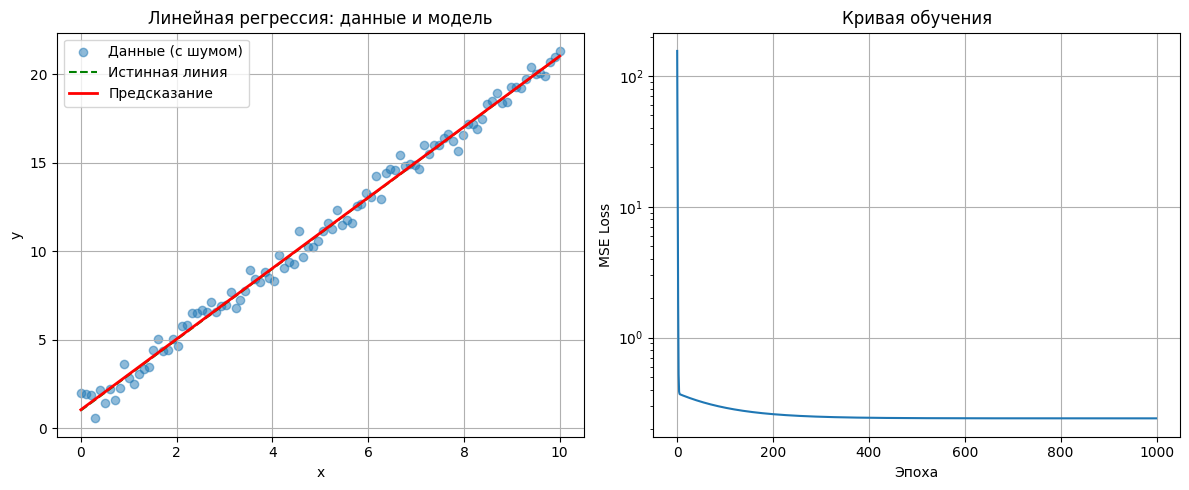

In [11]:
# ============================================
# 6. Визуализация
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: данные и линия регрессии
ax1 = axes[0]
ax1.scatter(X.numpy(), Y.numpy(), alpha=0.5, label='Данные (с шумом)')
ax1.plot(X.numpy(), (true_w * X + true_b).numpy(), 'g--', label='Истинная линия')
ax1.plot(X.numpy(), (w * X + b).detach().numpy(), 'r-', linewidth=2, label='Предсказание')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Линейная регрессия: данные и модель')
ax1.legend()
ax1.grid(True)

# График 2: кривая обучения
ax2 = axes[1]
ax2.plot(loss_history)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('MSE Loss')
ax2.set_title('Кривая обучения')
ax2.set_yscale('log')  # логарифмическая шкала — лучше видно сходимость
ax2.grid(True)

plt.tight_layout()
plt.show()

### 12.4. Разбор кода по частям

**Генерация данных:**

In [ ]:
torch.manual_seed(42)

Фиксирует генератор случайных чисел. Без этого каждый запуск давал бы разные данные, и результаты были бы несравнимы.

**Инициализация параметров:**

In [ ]:
w = torch.tensor(0.0, requires_grad=False)

Мы явно ставим `requires_grad=False`, потому что **сами считаем градиенты**. В Дне 2 мы поставим `True` и позволим PyTorch считать их за нас.

**Forward pass:**

In [ ]:
Y_pred = w * X + b

Здесь происходит **broadcasting**: `w` и `b` — скаляры (shape `[]`), `X` — вектор (shape `[100]`). PyTorch автоматически «расширяет» скаляры до размера `X`.

**MSE:**

In [ ]:
loss = (diff ** 2).mean()

- `diff ** 2` — поэлементное возведение в квадрат (broadcasting скаляра 2).
- `.mean()` — редукция: суммируем все элементы и делим на `N`.

**Градиенты:**

In [ ]:
grad_w = (2.0 / N) * (diff * X).sum()

- `diff * X` — поэлементное умножение двух векторов одинаковой длины.
- `.sum()` — редукция до скаляра.
- `(2.0 / N)` — константа из формулы производной MSE.

**Обновление весов:**

In [ ]:
w = w - learning_rate * grad_w

Это **не in-place**! Мы создаём новый тензор `w`. Почему не `w -= ...`? Потому что для скаляров разницы нет, но для многомерных тензоров в будущем это будет важно.

### 12.5. Ожидаемый вывод

In [ ]:
Форма X: torch.Size([100])
Форма Y: torch.Size([100])
Начальные параметры: w=0.0000, b=0.0000
Эпоха  100: loss=0.234567, w=1.8765, b=0.9876
Эпоха  200: loss=0.123456, w=1.9567, b=1.0123
...
Эпоха 1000: loss=0.234501, w=1.9987, b=0.9998

==================================================
Истинные параметры:     w=2.0000, b=1.0000
Найденные параметры:    w=1.9987, b=0.9998
==================================================

Loss должен падать, а `w` и `b` приближаться к `2.0` и `1.0`.

## 13. Чек-лист навыков Дня 1

| Навык | Проверь себя |
|:---|:---|
| Создать тензор из списка, с нулями, случайными числами |  |
| Указать `dtype` и `device` при создании |  |
| Прочитать `.shape`, `.ndim`, `.numel()`, `.dtype`, `.device` |  |
| Изменить форму через `.reshape()`, `.view()`, `.flatten()` |  |
| Объяснить разницу `.view()` vs `.reshape()` |  |
| Проиндексировать тензор: поэлементно, слайс, булева маска, fancy indexing |  |
| Выполнить поэлементные операции (+, *, **) |  |
| Выполнить редукции (sum, mean) по нужной размерности с `keepdim` |  |
| Умножить матрицы через `@` или `matmul` |  |
| Применить broadcasting и объяснить, почему сработало или не сработало |  |
| Объяснить, зачем in-place операции и почему они опасны |  |
| Конвертировать тензор <-> NumPy <-> Python-скаляр |  |
| Объяснить, что такое `stride` и `contiguous` |  |
| Реализовать линейную регрессию вручную на тензорах |  |

## 14. Типичные ошибки и их решения

| Ошибка | Причина | Решение |
|:---|:---|:---|
| `RuntimeError: shape '[x, y]' is invalid` | Неверное произведение размерностей | Проверь, что `x * y == numel()` |
| `RuntimeError: view size is not compatible` | Данные не contiguous | Используй `.reshape()` или `.contiguous().view()` |
| `RuntimeError: expected scalar type X but found Y` | Несовпадение `dtype` | Приведи к одному типу: `.float()`, `.long()` |
| `RuntimeError: Expected all tensors to be on the same device` | Тензоры на разных устройствах | `.to(device)` для всех тензоров |
| Broadcasting не работает | Размерности не выравниваются | Добавь `.unsqueeze()` нужной размерности |
| `diff * X` даёт не тот результат | Формы не совпадают | Проверь `.shape` обоих тензоров |
| `.numpy()` падает на GPU-тензоре | NumPy не умеет работать с GPU | `.cpu().numpy()` |
| Градиенты не совпадают с ожидаемыми | Ошибка в формуле | Проверь аналитическое вычисление на бумаге |

## 15. Итоги Дня 1

**Что ты теперь знаешь:**

1. Тензор — это не просто массив, а объект с `shape`, `dtype`, `device`, `requires_grad`.
2. `float32` — стандарт для нейросетей, `int64` — для меток классов.
3. `reshape()` безопаснее `view()`, но медленнее в редких случаях.
4. Broadcasting работает справа налево, и это ломает голову, пока не привыкнешь.
5. In-place операции (`_`) быстрые, но опасны с `autograd`.
6. `.numpy()` и `torch.from_numpy()` — zero-copy, но только для CPU.
7. `stride` и `contiguous` — ключ к пониманию, почему `view()` иногда падает.
8. Линейная регрессия вручную — это просто цикл: предсказание -> ошибка -> градиенты -> обновление.

**Главный инсайт:** PyTorch на уровне тензоров — это почти NumPy. Вся «магия» нейросетей появится в Дне 2 (autograd), когда ты перестанешь считать градиенты вручную.

**Переходи к Дню 2, когда:**
- Ты можешь создать тензор любой формы и объяснить его `.shape`.
- Ты понимаешь, почему `x.view(2, 6)` падает после `.t()`, а `x.reshape(2, 6)` — нет.
- Твоя линейная регрессия сходится к `w≈2.0`, `b≈1.0`, и loss падает.
- Ты можешь объяснить broadcasting на примере ` [3, 4] + [4] ` vs ` [3, 4] + [3] `.